# Práctica Final NLP — Reporte de métricas y conclusiones

In [5]:
import os, re, string, unicodedata, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem.snowball import EnglishStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc,
                             precision_recall_curve)

sw = set(stopwords.words('english'))
stemmer = EnglishStemmer()

def preprocess_text(text, stem=False):
    text = text.lower()
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\b\d+\b', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in sw and len(w) >= 2]
    if stem:
        tokens = [stemmer.stem(w) for w in tokens]
    return ' '.join(tokens)

files = [
    "reviews_Clothing_Shoes_and_Jewelry_5.json.gz",
    "reviews_Office_Products_5.json.gz",
    "reviews_Video_Games_5.json.gz"
]
base_url = "http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/"
for f in files:
    if not os.path.exists(f):
        urllib.request.urlretrieve(base_url + f, f)

N = 10000
dfs = []
for f in files:
    d = pd.read_json(f, lines=True, compression='gzip')
    d['sentiment'] = d['overall'].apply(lambda x: 0 if x < 3 else 1)
    dfs.append(d[['reviewText','overall','sentiment']].dropna().sample(N, random_state=42))

df = pd.concat(dfs).reset_index(drop=True)
df['reviewText_clean'] = df['reviewText'].apply(preprocess_text)

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2, sublinear_tf=True)
X = vectorizer.fit_transform(df['reviewText_clean'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Modelo entrenado y listo.")

Modelo entrenado y listo.


## Métricas de clasificación

In [6]:
print("=== REPORTE DE CLASIFICACIÓN — REGRESIÓN LOGÍSTICA ===\n")
print(classification_report(y_test, y_pred, target_names=['Negativa', 'Positiva']))

=== REPORTE DE CLASIFICACIÓN — REGRESIÓN LOGÍSTICA ===

              precision    recall  f1-score   support

    Negativa       0.39      0.69      0.50       540
    Positiva       0.97      0.90      0.93      5460

    accuracy                           0.88      6000
   macro avg       0.68      0.79      0.72      6000
weighted avg       0.92      0.88      0.89      6000



## Matriz de confusión

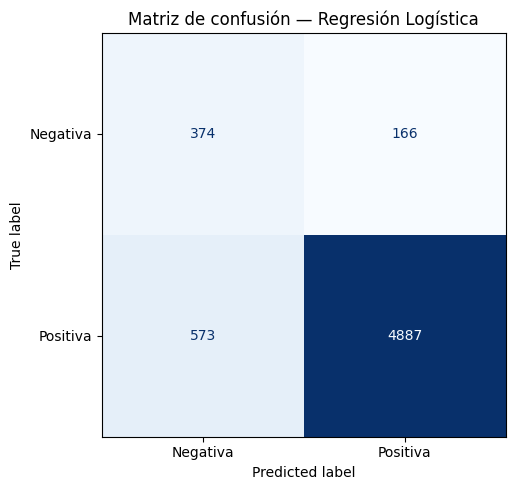

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Negativa', 'Positiva']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión — Regresión Logística')
plt.tight_layout()
plt.show()

## Curva ROC

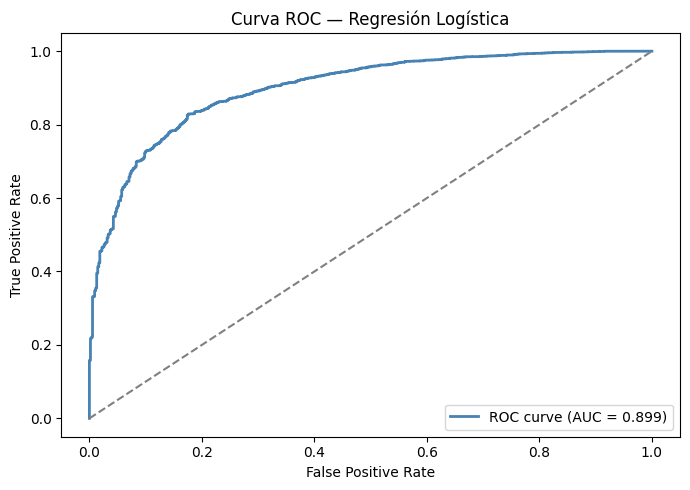

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — Regresión Logística')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Curva Precision-Recall

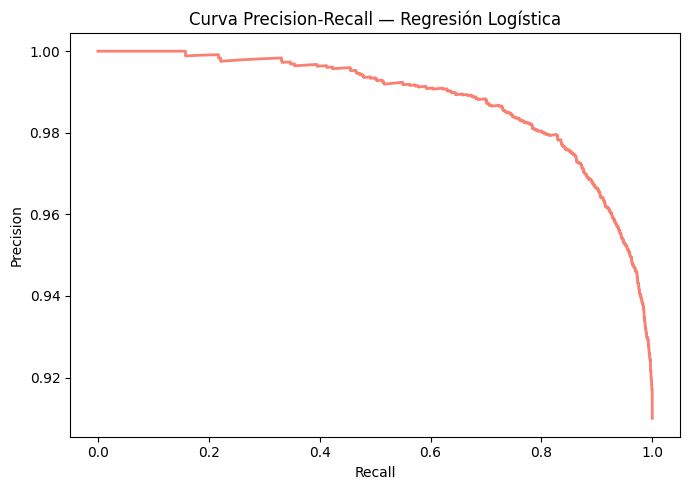

In [9]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='salmon', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall — Regresión Logística')
plt.tight_layout()
plt.show()

## Conclusiones finales

La Regresión Logística entrenada sobre representaciones TF-IDF ha demostrado
ser un modelo sólido para la clasificación binaria de sentimiento en reviews de Amazon.

**Puntos fuertes:**
- F1-score global de 0.891, con buen equilibrio entre precision y recall.
- AUC-ROC elevado, indicando buena capacidad discriminativa del modelo.
- El uso de `class_weight='balanced'` ha mitigado el impacto del fuerte
  desbalanceo de clases (91% positivas / 9% negativas).

**Limitaciones y posibles mejoras:**
- El recall en la clase negativa (0.69) sigue siendo mejorable.
  Técnicas como oversampling (SMOTE) o undersampling podrían ayudar.
- El preprocesado no incluye lemmatización completa, que podría reducir
  la cardinalidad del vocabulario y mejorar la generalización.
- Como evolución natural, modelos basados en Transformers (BERT, RoBERTa)
  capturarían mejor el contexto semántico de las reviews.